# Skeleton homelessness study with imperfect classification and heterogeneous policy

This notebook builds the first application-facing version of the housing queue model.

There are two true classes:

- chronic homeless
- transient homeless

The system cannot observe true class directly. Instead, each arrival is assigned a predicted label by a classifier with asymmetric false positive and false negative rates.

The study compares:

- a **better classifier**
- a **worse classifier**

and allows the scheduling policy to depend on classifier quality.

The main outcome is

$$
P(\text{abandon} \mid \text{true chronic})
$$

and the patience distributions are chosen to have **non-monotone hazard**, so that TIQ-style scheduling is meaningful.

## Study design

Each arriving customer has:

- a true class
- an assigned class from the classifier

The queueing policy acts on the assigned class, while outcomes are evaluated on the true class.

We compare two policy environments:

### Better classifier
Assigned chronic customers receive very strong priority.

### Worse classifier
Assigned chronic customers still receive higher priority, but assigned transient customers are given a nonzero index so they are not fully ignored.

This reflects the idea that when classification is noisier, the policy should be less extreme.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gi_gi_n_gi_multiclass.core.engine_multi import run_sim_multi
from gi_gi_n_gi_multiclass.core.types_multi import CustomerClass, MultiSimConfig
from gi_gi_n_gi_multiclass.dists.common import Exponential, LogNormal
from gi_gi_n_gi_multiclass.labelling import ConfusionMatrixClassifier

from gi_gi_n_gi_multiclass.metrics.class_metrics import (
    abandonment_probability_by_true_class,
    abandonment_probability_by_assigned_class,
    realized_confusion_table,
)
from gi_gi_n_gi_multiclass.outputs.tables import class_level_summary

from gi_gi_n_gi_multiclass.policies.priority_fcfs import PriorityFCFS
from gi_gi_n_gi_multiclass.policies.mtiq import MTIQ
from gi_gi_n_gi_multiclass.fluid.threshold_solver import solve_two_threshold_fluid

## Basic system parameters

We work with an overloaded two-class housing queue.

The chronic class is the intended priority population.

The transient class represents lower-priority demand.

Both classes are given patience distributions with non-monotone hazard, using lognormal patience times.

In [16]:
N_SERVERS = 10
MU = 1.0

LAMBDA_CHRONIC = 15.0
LAMBDA_TRANSIENT = 20.0

warmup_time = 500.0
run_time = 3000.0
seeds = [1, 2, 3, 4, 5]

In [17]:
true_chronic = CustomerClass(
    name="chronic",
    interarrival=Exponential(rate=LAMBDA_CHRONIC),
    service=Exponential(rate=MU),
    patience=LogNormal(meanlog=0.3, sdlog=1.0),
)

true_transient = CustomerClass(
    name="transient",
    interarrival=Exponential(rate=LAMBDA_TRANSIENT),
    service=Exponential(rate=MU),
    patience=LogNormal(meanlog=0.0, sdlog=0.9),
)

classes = [true_chronic, true_transient]

## Classifier cases

We use asymmetric confusion matrices.

Rows correspond to true class and columns to assigned class.

So the matrix entry in row $i$ and column $j$ is

$$
P(\hat C = j \mid C = i).
$$

This allows false negatives and false positives to differ.

In [18]:
classifier_cases = {
    "better_classifier": np.array([
        [0.90, 0.10],   # chronic correctly identified with high probability
        [0.20, 0.80],   # transient sometimes falsely labeled chronic
    ]),
    "worse_classifier": np.array([
        [0.70, 0.30],   # more chronic false negatives
        [0.35, 0.65],   # more transient false positives
    ]),
}

## Threshold initialization for TIQ

Because patience hazards are non-monotone, we initialize within-class TIQ thresholds using the fluid threshold solver.

For the skeleton study, we solve thresholds separately for each true class using the corresponding patience model and nominal service capacity.

In [19]:
sol_chronic = solve_two_threshold_fluid(
    objective="queue_length",
    patience=true_chronic.patience,
    lam=LAMBDA_CHRONIC,
    n_servers=N_SERVERS,
    mean_service=1.0,
)

sol_transient = solve_two_threshold_fluid(
    objective="queue_length",
    patience=true_transient.patience,
    lam=LAMBDA_TRANSIENT,
    n_servers=N_SERVERS,
    mean_service=1.0,
)

sol_chronic, sol_transient

(FluidSolution(w_l=0.7170684578868411, w_h=0.9751877209784648, p=0.3595894267303343, level=0.6184208097999584, obj_value=0.7547314582030551),
 FluidSolution(w_l=0.6317979070034411, w_h=1.00298588450855, p=0.006730095311484469, level=0.8862367888195977, obj_value=0.7759751515617731))

## Policy choices

We let the policy depend on classifier quality.

### Better classifier
Assigned chronic customers receive strong priority.

This is represented by a large difference in the cross-class indices

$$
\beta_0(n) \gg \beta_1(n).
$$

### Worse classifier
Assigned chronic customers still have priority, but assigned transient customers receive a nonzero priority index.

This reflects the idea that when the classifier is noisier, the policy should be less extreme.

In [20]:
policy_cases = {
    "better_classifier": MTIQ(
        beta=[
            lambda n: 5.0,   # assigned chronic
            lambda n: 1.0,   # assigned transient
        ],
        w_l=[sol_chronic.w_l, sol_transient.w_l],
        w_h=[sol_chronic.w_h, sol_transient.w_h],
        name="MTIQ_better",
    ),
    "worse_classifier": MTIQ(
        beta=[
            lambda n: 3.0,   # assigned chronic
            lambda n: 1.5,   # assigned transient gets nonzero weight
        ],
        w_l=[sol_chronic.w_l, sol_transient.w_l],
        w_h=[sol_chronic.w_h, sol_transient.w_h],
        name="MTIQ_worse",
    ),
}

## Scenario runner

For each classifier case we pair:

- the corresponding confusion matrix
- the corresponding policy

The main outputs are:

- chronic abandonment probability
- transient abandonment probability
- assigned-class abandonment probabilities
- overall queueing statistics

In [21]:
def run_case(case_name: str, seed: int) -> dict:
    classifier = ConfusionMatrixClassifier(classifier_cases[case_name])
    policy = policy_cases[case_name]

    cfg = MultiSimConfig(
        n_servers=N_SERVERS,
        classes=classes,
        classifier=classifier,
        policy=policy,
        seed=seed,
        warmup_time=warmup_time,
        run_time=run_time,
        collect_event_log=False,
    )

    res = run_sim_multi(cfg)
    summ = class_level_summary(res)
    overall = summ[summ["scope"] == "OVERALL"].iloc[0]

    return {
        "case": case_name,
        "seed": seed,
        "rho": (LAMBDA_CHRONIC + LAMBDA_TRANSIENT) / (N_SERVERS * MU),
        "true_chronic_abandon_prob": abandonment_probability_by_true_class(res, 0),
        "true_transient_abandon_prob": abandonment_probability_by_true_class(res, 1),
        "assigned_chronic_abandon_prob": abandonment_probability_by_assigned_class(res, 0),
        "assigned_transient_abandon_prob": abandonment_probability_by_assigned_class(res, 1),
        "served_rate": overall["served_rate"],
        "abandon_rate": overall["abandon_rate"],
        "L_timeavg": overall["L_timeavg"],
        "Lq_timeavg": overall["Lq_timeavg"],
        "result": res,
    }

## Run the skeleton study

We run both cases across multiple seeds and aggregate the results.

In [22]:
rows = []

for case_name in classifier_cases.keys():
    for seed in seeds:
        rows.append(run_case(case_name, seed))

results = pd.DataFrame(rows)
results[[
    "case",
    "seed",
    "true_chronic_abandon_prob",
    "true_transient_abandon_prob",
    "served_rate",
    "abandon_rate",
    "Lq_timeavg",
]]

,case,seed,true_chronic_abandon_prob,true_transient_abandon_prob,served_rate,abandon_rate,Lq_timeavg
0,better_classifier,1,0.465257,0.900698,9.999000,25.049333,42.446657
1,better_classifier,2,0.469483,0.903577,9.893667,25.105000,42.546332
2,better_classifier,3,0.457207,0.901117,10.066333,24.850000,42.016291
3,better_classifier,4,0.461485,0.902654,9.974667,25.014667,42.177306
4,better_classifier,5,0.469487,0.902073,9.902000,25.008333,42.243136
5,worse_classifier,1,0.572907,0.821785,9.967000,25.081667,44.087701
6,worse_classifier,2,0.570964,0.824371,9.946000,25.052000,44.046320
7,worse_classifier,3,0.564056,0.819320,10.105000,24.810667,43.431320
8,worse_classifier,4,0.567298,0.820292,10.048333,24.938667,43.338250
9,worse_classifier,5,0.576188,0.822185,9.888667,25.021667,43.622022


In [23]:
summary = (
    results.groupby("case")[[
        "true_chronic_abandon_prob",
        "true_transient_abandon_prob",
        "assigned_chronic_abandon_prob",
        "assigned_transient_abandon_prob",
        "served_rate",
        "abandon_rate",
        "L_timeavg",
        "Lq_timeavg",
    ]]
    .agg(["mean", "std"])
)

summary

true_chronic_abandon_prob            \
                                       mean       std   
case                                                    
better_classifier                  0.464584  0.005304   
worse_classifier                   0.570283  0.004741   

                  true_transient_abandon_prob            \
                                         mean       std   
case                                                      
better_classifier                    0.902024  0.001161   
worse_classifier                     0.821591  0.001934   

                  assigned_chronic_abandon_prob            \
                                           mean       std   
case                                                        
better_classifier                      0.430622  0.004594   
worse_classifier                       0.430170  0.006115   

                  assigned_transient_abandon_prob           served_rate  \
                                             mean       std        mean   
case                                                                      
better_classifier                         0.99853  0.000238    9.967133   
worse_classifier                          0.99828  0.000260    9.991000   

                            abandon_rate            L_timeavg            \
                        std         mean       std       mean       std   
case                                                                      
better_classifier  0.071681    25.005467  0.094992  52.285945  0.212119   
worse_classifier   0.085668    24.980933  0.109126  53.705122  0.346140   

                  Lq_timeavg            
                        mean       std  
case                                    
better_classifier  42.285945  0.212119  
worse_classifier   43.705122  0.346140

## Realized confusion tables

It is useful to confirm that the two classifier cases produce noticeably different observed assignment patterns.

In [24]:
for case_name in classifier_cases.keys():
    res0 = results.loc[results["case"] == case_name, "result"].iloc[0]
    print("\n===", case_name, "===")
    print(realized_confusion_table(res0))


=== better_classifier ===
assigned_class_id      0      1
true_class_id                  
0                  40605   4411
1                  12081  48099

=== worse_classifier ===
assigned_class_id      0      1
true_class_id                  
0                  31629  13387
1                  21100  39080


## Main comparison plot

The main outcome is the probability that a truly chronic person abandons.

This plot gives the first application-level comparison between a better and a worse classifier-policy environment.

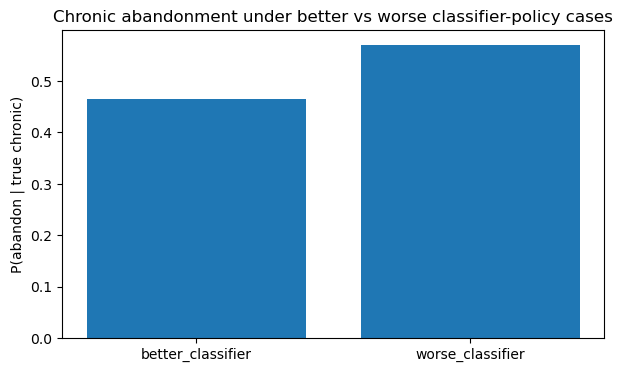

In [25]:
plot_df = (
    results.groupby("case")[[
        "true_chronic_abandon_prob",
        "true_transient_abandon_prob",
    ]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))
plt.bar(plot_df["case"], plot_df["true_chronic_abandon_prob"])
plt.ylabel("P(abandon | true chronic)")
plt.title("Chronic abandonment under better vs worse classifier-policy cases")
plt.show()

## Optional comparison for transient abandonment

This plot helps visualize the tradeoff: protecting the chronic population more effectively may increase abandonment among the transient population.

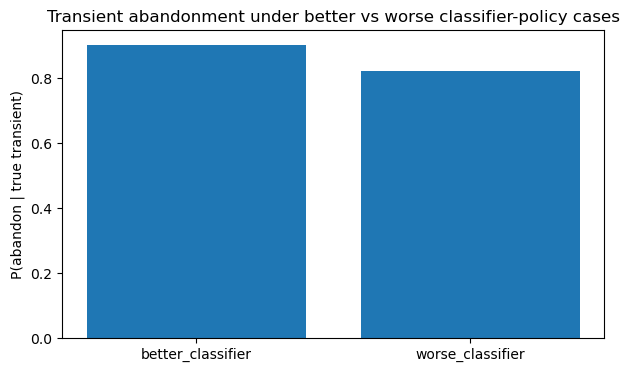

In [26]:
plt.figure(figsize=(7, 4))
plt.bar(plot_df["case"], plot_df["true_transient_abandon_prob"])
plt.ylabel("P(abandon | true transient)")
plt.title("Transient abandonment under better vs worse classifier-policy cases")
plt.show()

## Interpretation

This skeleton study is not yet a calibrated homelessness model.

Its purpose is to establish the full application pipeline:

- latent true classes
- imperfect and asymmetric classification
- policy based on assigned class
- evaluation based on true class
- non-monotone patience hazards
- policy adaptation to classifier quality

Once this structure is working, the next stage is to vary:

- overload
- classifier quality
- policy aggressiveness
- patience assumptions

in a more systematic study.